In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## **Load mall dataset and inspect income and spending score columns:**

In [ ]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df_new1=df.drop(columns='CustomerID')
df_new=df.drop(columns='CustomerID')

## **Apply StandardScaler to features for balanced distance calculation:**

In [ ]:
scaler=StandardScaler().set_output(transform="pandas")
x=scaler.fit_transform(df_new.drop(columns=['Age','Genre']))
x

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980
...,...,...
195,2.268791,1.118061
196,2.497807,-0.861839
197,2.497807,0.923953
198,2.917671,-1.250054


## **Plot elbow curve to decide optimal number of clusters:**

In [ ]:
inertia=[]
for k in range(1,11):
  km=KMeans(n_clusters=k,random_state=42)
  km.fit(x)
  inertia.append(km.inertia_)

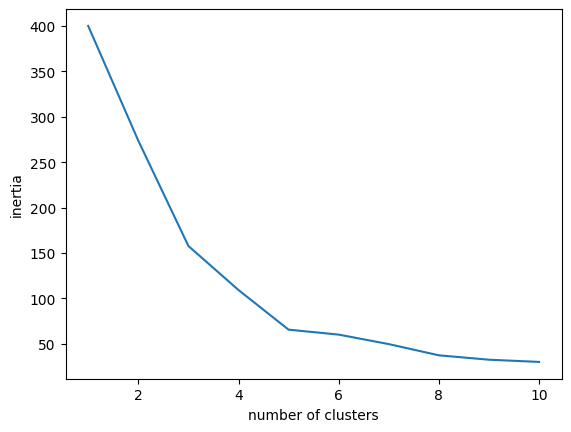

In [ ]:
plt.plot(range(1,11),inertia)
plt.xlabel("number of clusters")
plt.ylabel("inertia")
plt.savefig("inertia.png")
plt.show()

## **Train KMeans with selected K value:**

In [ ]:
km=KMeans(n_clusters=5,random_state=42)
clusters=res=km.fit_predict(x)

## **Add cluster labels back into dataset:**

In [ ]:
df_new1['clusters']=clusters

In [ ]:
df_new1.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),clusters
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4



## **Visualize clusters using scatter plot:**

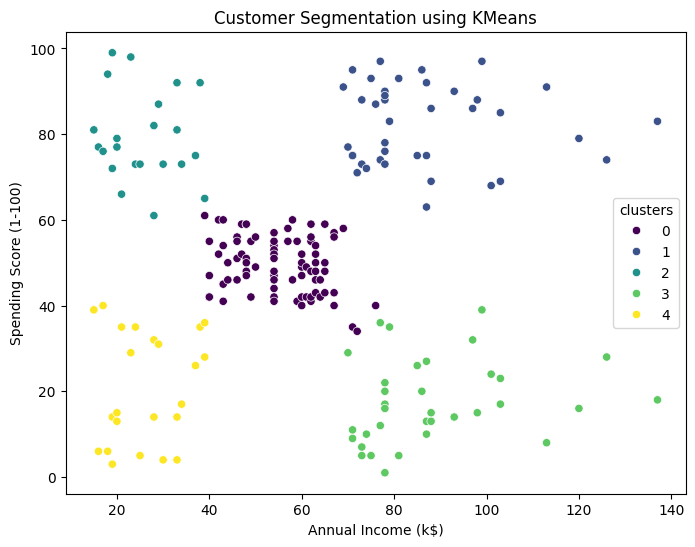

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_new1["Annual Income (k$)"],
    y=df_new1["Spending Score (1-100)"],
    hue=df_new1["clusters"],
    palette="viridis"
)
plt.title("Customer Segmentation using KMeans")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.savefig('customer_segmentation_k_means.png')
plt.show()

## **Interpret each cluster and label them as customer types:**

### **Description about clusters:**


| **Cluster** | **Income Level** | **Spending Level** | **Customer Type Label** | **Interpretation**                                                        |
| ----------- | ---------------- | ------------------ | ----------------------- | ------------------------------------------------------------------------- |
| **0**       | Medium           | Medium             | **Average Customers**   | Customers with balanced income and spending; form the core customer base. |
| **1**       | High             | High               | **Premium Customers**   | High-income customers who spend heavily; most valuable segment.           |
| **2**       | Low              | High               | **Impulsive Customers** | Spend a lot despite lower income; influenced by discounts and offers.     |
| **3**       | High             | Low                | **Careful Customers**   | High income but low spending; selective and quality-focused buyers.       |
| **4**       | Low              | Low                | **Low-Value Customers** | Low income and low spending; least contribution to revenue.               |
